[*********************100%***********************]  5 of 5 completed


Ticker      HDFCBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS    WIPRO.NS
Date                                                                      
2026-03-09   840.700012  1315.000000  1424.000000  2527.399902  198.750000
2026-03-10   849.450012  1295.599976  1408.800049  2513.100098  200.929993
2026-03-11   833.950012  1276.300049  1390.199951  2464.899902  202.229996
2026-03-12   832.750000  1265.800049  1392.199951  2442.399902  202.509995
2026-03-13   817.000000  1248.300049  1380.699951  2410.500000  197.580002


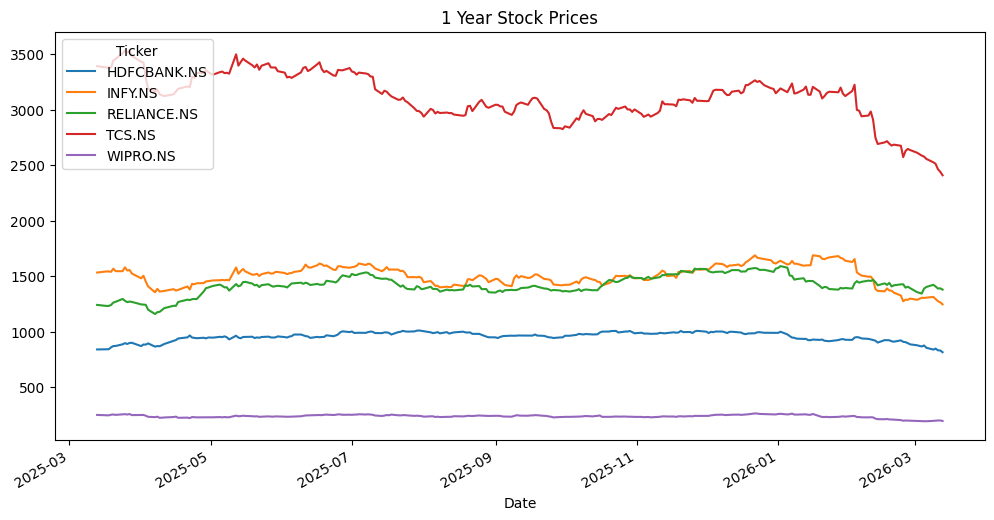

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Download 1 year of data for 5 Indian stocks
tickers = ["RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS", "WIPRO.NS"]

data = yf.download(tickers, period="1y", interval="1d")

# Look at closing prices
close = data['Close']
print(close.tail())

# Plot it
close.plot(figsize=(12,6), title="1 Year Stock Prices")
plt.show()

# Save to CSV
close.to_csv("../data/stock_prices.csv")

[*********************100%***********************]  1 of 1 completed


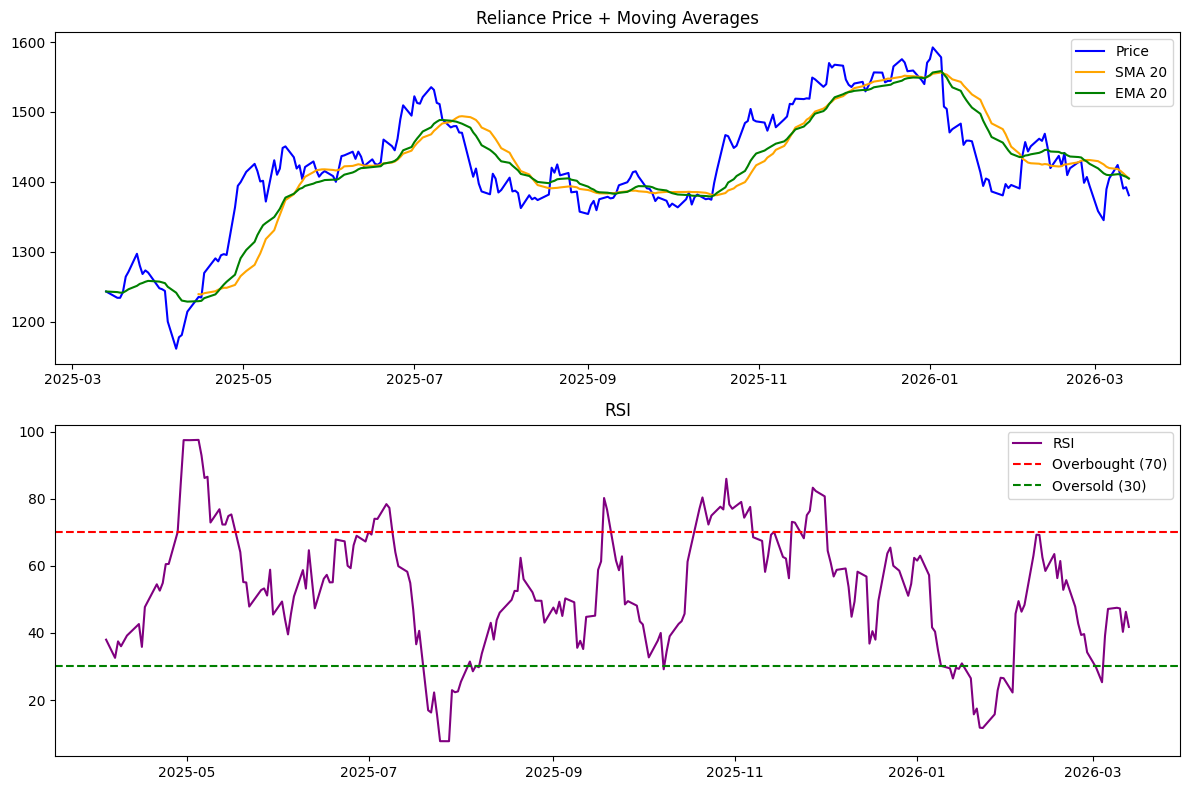

In [4]:
import yfinance as yf
import matplotlib.pyplot as plt

reliance = yf.download("RELIANCE.NS", period="1y", auto_adjust=True)

# Calculate manually - no pandas_ta needed
reliance['SMA_20'] = reliance['Close'].rolling(window=20).mean()
reliance['EMA_20'] = reliance['Close'].ewm(span=20, adjust=False).mean()

# Calculate RSI manually
delta = reliance['Close'].diff()
gain = delta.clip(lower=0).rolling(window=14).mean()
loss = -delta.clip(upper=0).rolling(window=14).mean()
rs = gain / loss
reliance['RSI'] = 100 - (100 / (1 + rs))

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(reliance['Close'], label='Price', color='blue')
ax1.plot(reliance['SMA_20'], label='SMA 20', color='orange')
ax1.plot(reliance['EMA_20'], label='EMA 20', color='green')
ax1.legend()
ax1.set_title("Reliance Price + Moving Averages")

ax2.plot(reliance['RSI'], label='RSI', color='purple')
ax2.axhline(70, color='red', linestyle='--', label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', label='Oversold (30)')
ax2.legend()
ax2.set_title("RSI")

plt.tight_layout()
plt.savefig("../data/reliance_chart.png")
plt.show()